## Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

%matplotlib inline

> **Nota aclaratoria:** La resolución y explicación de los ejercicios de este laboratorio han sido desarrolladas con la asistencia de Inteligencia Artificial, específicamente utilizando Google AI Studio y el modelo Gemini.

# Parte 1: Análisis del data frame

> **1. Leer el data frame en formato csv en la dirección https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv**

In [2]:
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
df = pd.read_csv(url)

# Visualización de las primeras filas
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


> **2. Entender el estado de los datos, para ello puedo emplear los comandos básicos del pandas:**
> * **df.info()**
> * **df.describe()**
> * **df.isnull().sum()**

In [3]:
# Resumen técnico: tipos de datos y valores no nulos
df.info()

# Resumen estadístico: tendencia central y dispersión
display(df.describe())

# Detección de valores faltantes
print("Valores nulos por columna:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Valores nulos por columna:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


> **3. ¿Cuántas variables tiene el dataset y de qué tipo son?**

El dataset tiene un total de **10 variables**. De estas, **9 son de tipo numérico** (específicamente de punto flotante `float64`) y **1 es de tipo categórico** (identificada como `object` en pandas).

> **4. ¿Existen valores faltantes? ¿En qué variables estan? ¿cuántos son?**

Sí, existen valores faltantes. Se encuentran únicamente en la variable **`total_bedrooms`** y el total es de **207** valores nulos.

> **5. Determinar los elementos únicos dentro de la columna ocean_proximity.**

 Los elementos únicos dentro de la columna son: **'NEAR BAY'**, **'<1H OCEAN'**, **'INLAND'**, **'NEAR OCEAN'** e **'ISLAND'**.

In [4]:
categorias_ocean = df["ocean_proximity"].unique()
print(f"Categorías únicas en ocean_proximity: {categorias_ocean}")

Categorías únicas en ocean_proximity: ['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


> **6. Para las columnas `cols = ["housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income", "median_house_value"]`**
>
> **Determinar el promedio de cada una de las columnas asociado a cada elementos unico de ocean_proximity, intenta con la operación groupby.**

In [5]:
cols = ["housing_median_age", "total_rooms", "total_bedrooms", "population",
        "households", "median_income", "median_house_value"]

# Agrupación y cálculo del promedio
resumen_ocean = df.groupby("ocean_proximity")[cols].mean()
display(resumen_ocean)

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
ocean_proximity,,,,,,,
<1H OCEAN,29.279225,2628.343586,546.539185,1520.290499,517.744965,4.230682,240084.285464
INLAND,24.271867,2717.742787,533.881619,1391.046252,477.447565,3.208996,124805.392001
ISLAND,42.400000,1574.600000,420.400000,668.000000,276.600000,2.744420,380440.000000
NEAR BAY,37.730131,2493.589520,514.182819,1230.317467,488.616157,4.172885,259212.311790
NEAR OCEAN,29.347254,2583.700903,538.615677,1354.008653,501.244545,4.005785,249433.977427


> **7. Construye un histograma para cada columna, puede emplear la libreria de seaborn.**

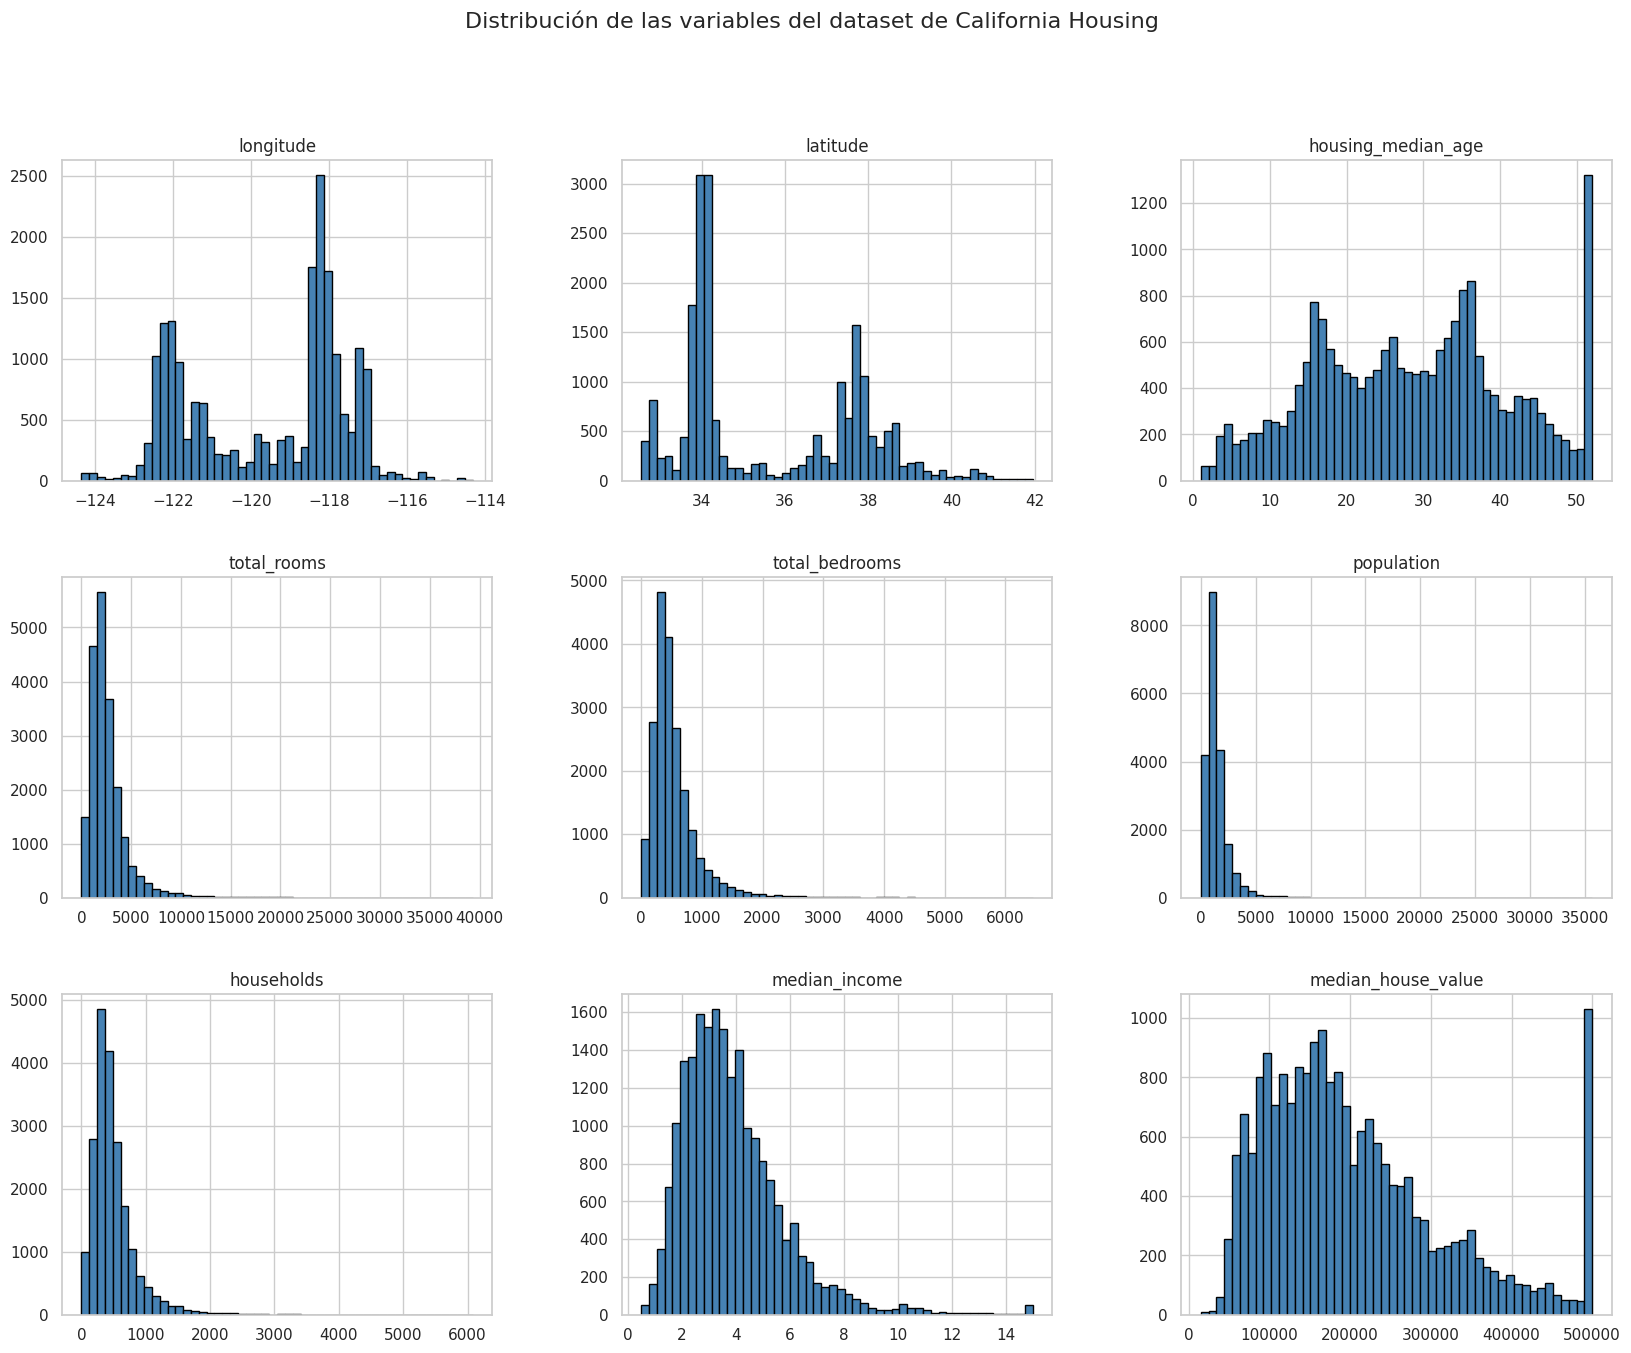

In [6]:
# Configuramos el estilo de las gráficas
sns.set_theme(style="whitegrid")

# Histogramas para las variables numéricas
df.hist(bins=50, figsize=(20, 15), color='steelblue', edgecolor='black')
plt.suptitle("Distribución de las variables del dataset de California Housing", fontsize=16)
plt.show()

### Interpretación de un diagrama de caja
> **El rango intercuartil $IQR = Q_3 - Q_1$ permite definir que datos pueden ser atípicos, basado en los siguientes limites:**
> * **$Max = Q_3 + 1.5IQR$**
> * **$Min = Q_1 - 1.5IQR$**

Arreglo ordenado: [52 57 57 58 63 66 66 67 67 68 69 70 70 70 70 72 73 75 75 76 76 78 79 89]
Límite Superior (Max): 88.5
Límite Inferior (Min): 52.5


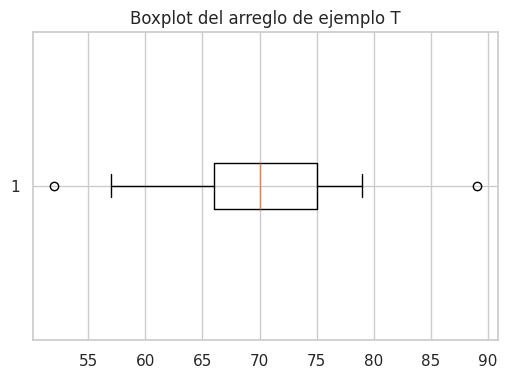

In [7]:
# Ejemplo con el arreglo T proporcionado en el laboratorio
T = np.array([52, 57, 57, 58, 63, 66, 66, 67, 67, 68, 69, 70, 70, 70, 70, 72, 73, 75, 75, 76, 76, 78, 79, 89])
Tsort = np.sort(T)

# Cálculos de cuartiles para el ejemplo
Q1_T = np.percentile(T, 25)
Q3_T = np.percentile(T, 75)
IQR_T = Q3_T - Q1_T
max_T = Q3_T + 1.5 * IQR_T
min_T = Q1_T - 1.5 * IQR_T

print(f"Arreglo ordenado: {Tsort}")
print(f"Límite Superior (Max): {max_T}")
print(f"Límite Inferior (Min): {min_T}")

plt.figure(figsize=(6, 4))
plt.boxplot(T, vert=False)
plt.title("Boxplot del arreglo de ejemplo T")
plt.show()

> **8. Empleando el siguiente código realiza el gráfico boxplot para comparar el precio por proximidad al océano.**

<Figure size 1200x600 with 0 Axes>

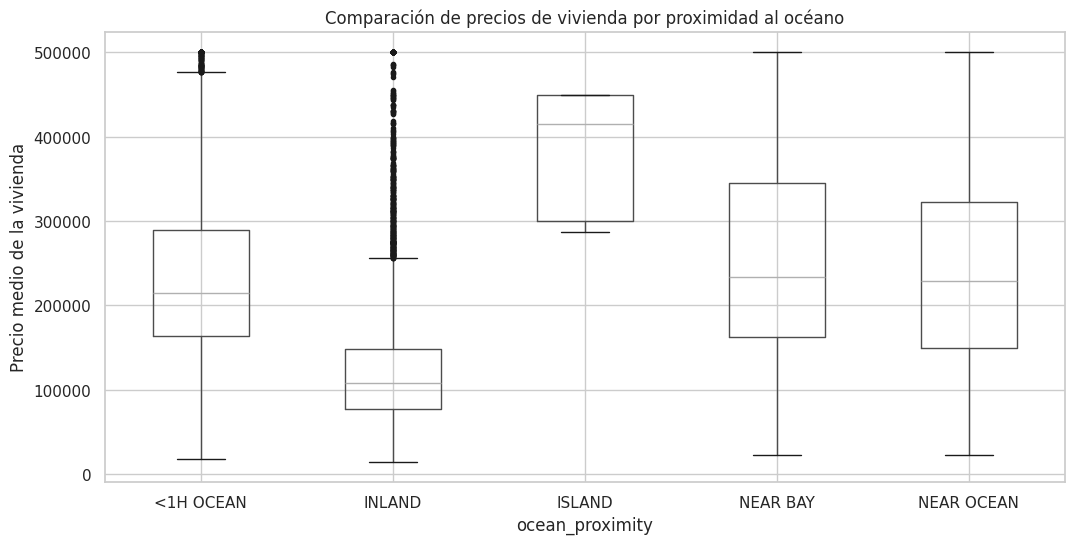

In [8]:
plt.figure(figsize=(12, 6))
df.boxplot(column="median_house_value", by='ocean_proximity', sym='k.', figsize=(12, 6))
plt.title('Comparación de precios de vivienda por proximidad al océano')
plt.suptitle("") # Elimina el título automático de pandas para limpieza visual
plt.ylabel("Precio medio de la vivienda")
plt.show()

> **9. Determina la matrix de correlación.**

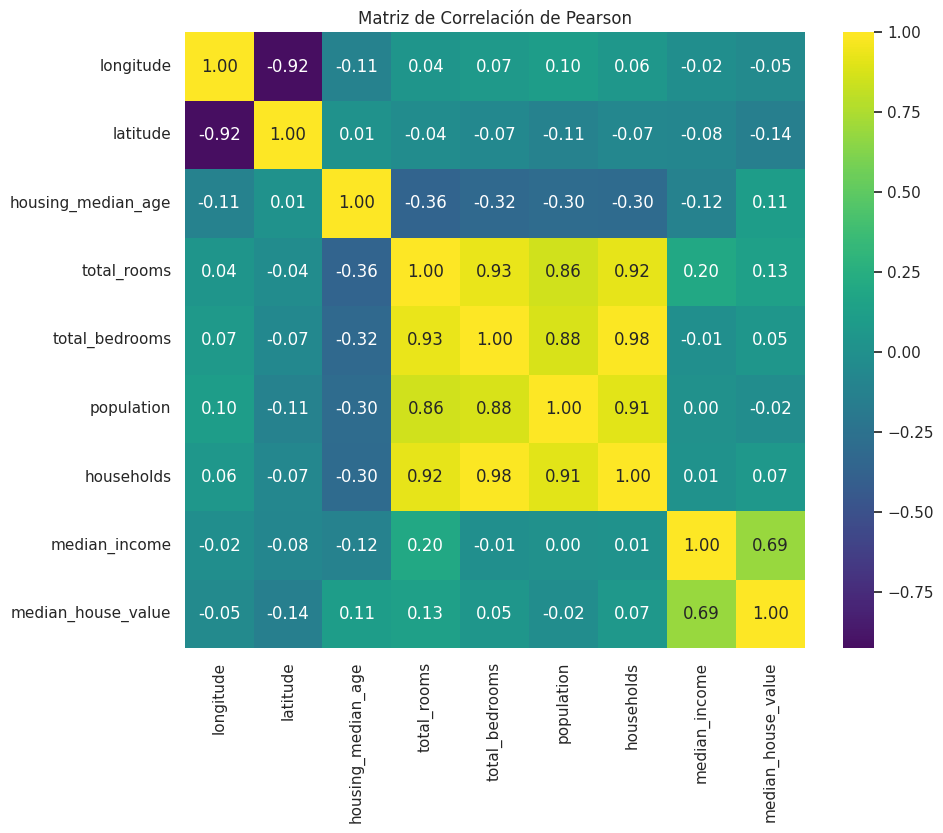

In [9]:
# Cálculo de la matriz de correlación (solo variables numéricas)
corr_matrix = df.corr(numeric_only=True)

# Visualización mediante Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="viridis", fmt=".2f", center=0)
plt.title("Matriz de Correlación de Pearson")
plt.show()

> **10. Realiza un grafico pairplot empleando seaborn de python.**

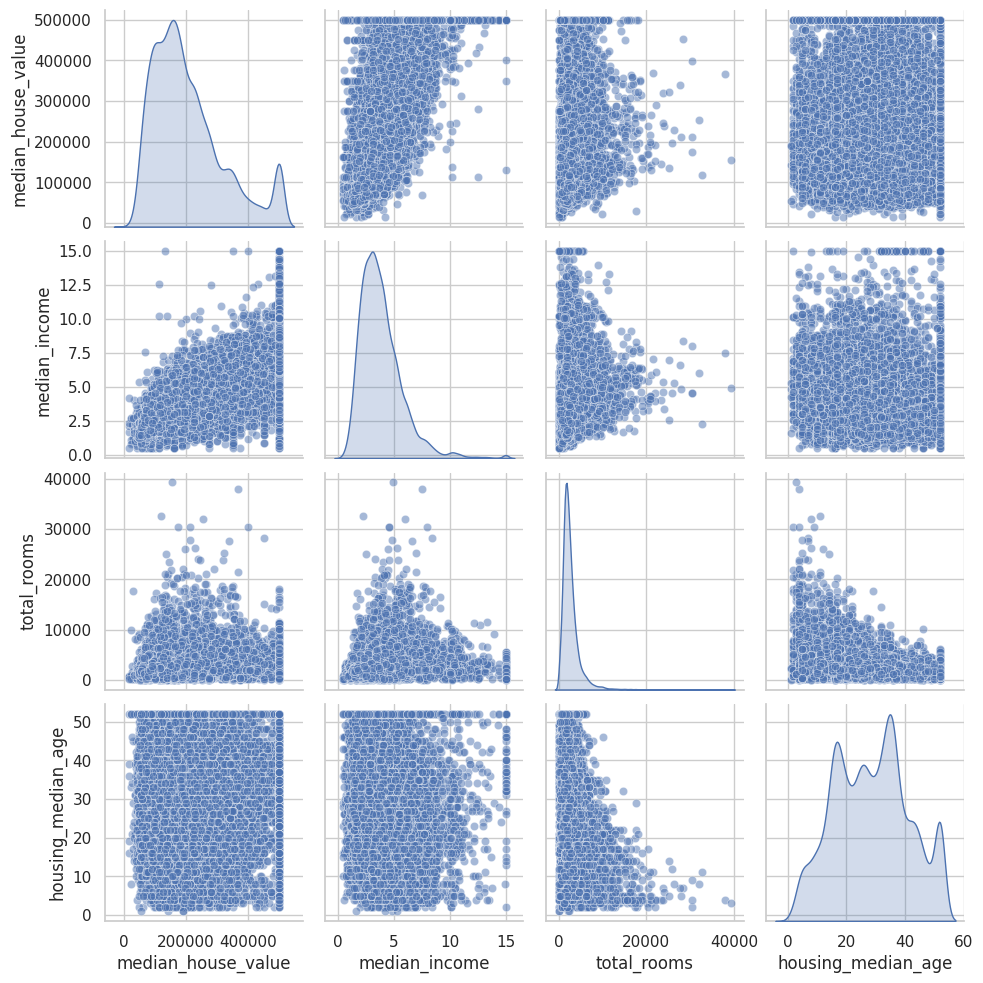

In [10]:
# Gráfico de pares (Pairplot) para variables clave
cols_interes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
sns.pairplot(df[cols_interes], diag_kind="kde", plot_kws={'alpha': 0.5})
plt.show()

> **11. Realiza un scatter plot, el color del grafico puede ser empleado con la columna median_house_value.**

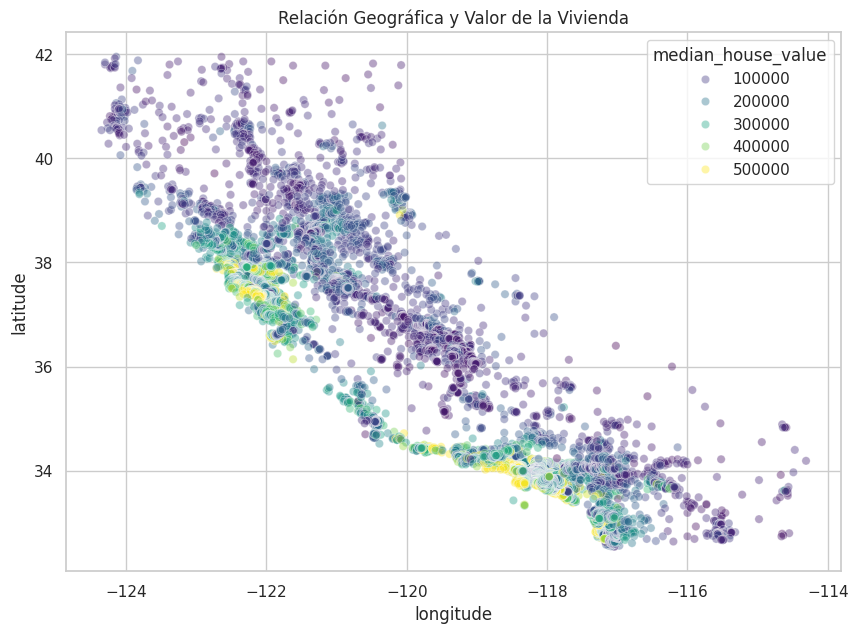

In [11]:
# Gráfico de dispersión geográfico con valor de vivienda como escala de color
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="longitude", y="latitude", hue="median_house_value",
                palette="viridis", alpha=0.4)
plt.title("Relación Geográfica y Valor de la Vivienda")
plt.show()

# Parte 2: Preparacion del data frame

**Evitar el data Snooping bias.**

En algunos casos se sugiere dividir los datos en entrenamiento y test desde el principio dado que el cerebro puede sobreajustar el dataset y los resultados no significativos se pueden volver significativos. El procedimiento correcto es probar cualquier hipótesis en un conjunto de datos que no se utilizó para generar las hipótesis inicial.

> **12. ¿Las siguiente linea es adecuada para separar el dataframe en datos de entrenamiento de test?, ¿que pasa en la división de los datos?**

In [12]:
# División aleatoria simple
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {len(train_set)}")
print(f"Tamaño del conjunto de prueba: {len(test_set)}")

Tamaño del conjunto de entrenamiento: 16512
Tamaño del conjunto de prueba: 4128


**Análisis del punto 12:** La línea es adecuada técnicamente, pero en términos estadísticos presenta un riesgo: si el dataset es pequeño o si la variable de interés tiene categorías muy desiguales, la división aleatoria puede sesgar el modelo. Para mitigar esto, procederemos a la estratificación.

> **13. División del dataset en grupos:**
>
> **La siguiente división puede ser realizada basada en la experticie de lo que se esta analizando, y sobre ello se debe tomar una muestra significativa.**

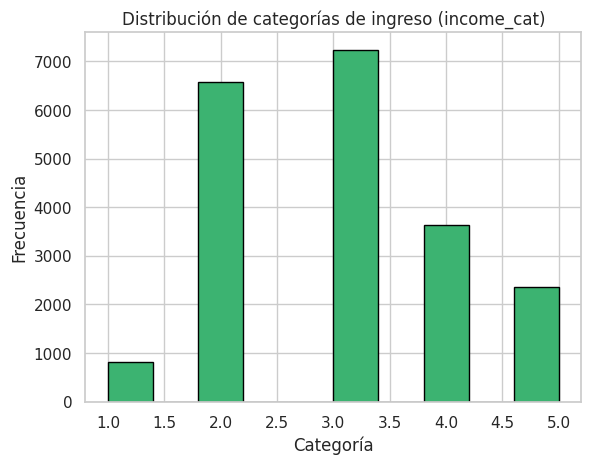

In [13]:
# Creación de categorías de ingreso
df["income_cat"] = pd.cut(df["median_income"],
                          bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                          labels=[1, 2, 3, 4, 5])

# Visualización de la distribución de las nuevas categorías
df["income_cat"].hist(color='mediumseagreen', edgecolor='black')
plt.title("Distribución de categorías de ingreso (income_cat)")
plt.xlabel("Categoría")
plt.ylabel("Frecuencia")
plt.show()

In [14]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

# División Estratificada
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

# Comparación (ahora test_set sí tiene la columna)
compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(df),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()

compare_props["Rand. %error"] = abs(100 * compare_props["Random"] / compare_props["Overall"] - 100)
compare_props["Strat. %error"] = abs(100 * compare_props["Stratified"] / compare_props["Overall"] - 100)

display(compare_props)

,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.039826,0.039971,0.040213,0.973236,0.364964
2,0.318847,0.318798,0.324370,1.732260,0.015195
3,0.350581,0.350533,0.358527,2.266446,0.013820
4,0.176308,0.176357,0.167393,5.056334,0.027480
5,0.114438,0.114341,0.109496,4.318374,0.084674


> **13. Puedes agregar nuevas variables al dataframe para el análisis, por ejemplo:**
> * **`rooms_per_household` = `total_rooms` / `households`**
> * **`bedrooms_per_room` = `total_bedrooms` / `total_rooms`**
> * **`population_per_household` = `population` / `households`**

In [15]:
# Trabajaremos sobre una copia del conjunto de entrenamiento estratificado
housing = strat_train_set.copy()

# Creación de nuevos atributos
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]

# Verificamos las correlaciones con la variable objetivo
corr_matrix = housing.corr(numeric_only=True)
print("Correlación de nuevos atributos con median_house_value:")
print(corr_matrix["median_house_value"].sort_values(ascending=False))

Correlación de nuevos atributos con median_house_value:
median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64


**Limpieza de datos**
> **Lo que sigue son códigos que pueden servir para limpiar los datos.**

In [16]:
# Identificación de nulos en el set actual
print(f"Valores nulos en total_bedrooms: {housing['total_bedrooms'].isnull().sum()}")

# Opción manual: Rellenar con la mediana
median = housing["total_bedrooms"].median()
housing["total_bedrooms"] = housing["total_bedrooms"].fillna(median)

print(f"Valores nulos tras limpieza: {housing['total_bedrooms'].isnull().sum()}")

Valores nulos en total_bedrooms: 158
Valores nulos tras limpieza: 0


**Imputer**
> **Forma automática para tratar los datos (Asegurate de trabajar con las columnas numéricas).**

In [17]:
# Creamos housing_num eliminando las columnas que no son números puros
# ocean_proximity (texto) e income_cat (categoría)
housing_num = housing.drop(["ocean_proximity", "income_cat"], axis=1, errors='ignore')

# Inicializamos y ajustamos el imputer con la estrategia de la mediana
imputer = SimpleImputer(strategy="median")
imputer.fit(housing_num)

print("Imputer ajustado exitosamente.")

Imputer ajustado exitosamente.


> **14. Compara las siguientes variables:**
> * **`imputer.statistics_`**
> * **`husing_num.median()`**

In [18]:
# Comparación de las estadísticas del imputer vs mediana manual de pandas
print(f"Estadísticas del imputer: {imputer.statistics_}")
print(f"Medianas calculadas por pandas: {housing_num.median().values}")

print("\n¿Coinciden los valores?")
print(np.allclose(imputer.statistics_, housing_num.median().values))

Estadísticas del imputer: [-1.18510000e+02  3.42600000e+01  2.90000000e+01  2.11900000e+03
  4.33000000e+02  1.16400000e+03  4.08000000e+02  3.54155000e+00
  1.79500000e+05  5.23234164e+00  2.03027043e-01  2.81766108e+00]
Medianas calculadas por pandas: [-1.18510000e+02  3.42600000e+01  2.90000000e+01  2.11900000e+03
  4.33000000e+02  1.16400000e+03  4.08000000e+02  3.54155000e+00
  1.79500000e+05  5.23234164e+00  2.03027043e-01  2.81766108e+00]

¿Coinciden los valores?
True


**Construcción de la matriz de características limpia**

In [19]:
# Aplicamos el imputer para rellenar los valores nulos en el dataset
X = imputer.transform(housing_num)

# Construimos el DataFrame limpio (housing_tr) conservando nombres de columnas e índices
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing.index)

# Verificamos que ya no existan valores nulos
print(f"Valores nulos totales en el nuevo DataFrame: {housing_tr.isnull().sum().sum()}")
housing_tr.head()

Valores nulos totales en el nuevo DataFrame: 0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,5.485836,0.205784,3.168555
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,6.927083,0.160714,2.623698
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,5.393333,0.191595,2.223333
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,3.886128,0.276505,1.859213
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,6.096552,0.182692,3.167241


> **15. ¿Qué realizan las siguientes lineas de código?**

In [20]:
from sklearn.preprocessing import OneHotEncoder

# Extraemos la columna categórica
housing_cat = housing[["ocean_proximity"]]

# Inicializamos el codificador
# sparse_output=False nos devuelve un array denso de Numpy (fácil de leer)
cat_encoder = OneHotEncoder(sparse_output=False)

# Ajustamos y transformamos
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

# Creamos un DataFrame con las nuevas columnas binarias
df_cat_1hot = pd.DataFrame(housing_cat_1hot,
                           columns=cat_encoder.categories_[0],
                           index=housing.index)

# Unimos los datos numéricos limpios con los datos categóricos codificados
housing_tr_combined = housing_tr.join(df_cat_1hot)

print("Categorías detectadas:", cat_encoder.categories_)
housing_tr_combined.head()

Categorías detectadas: [array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,5.485836,0.205784,3.168555,0.0,1.0,0.0,0.0,0.0
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,6.927083,0.160714,2.623698,0.0,0.0,0.0,0.0,1.0
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,5.393333,0.191595,2.223333,0.0,1.0,0.0,0.0,0.0
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,3.886128,0.276505,1.859213,0.0,0.0,0.0,0.0,1.0
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,6.096552,0.182692,3.167241,1.0,0.0,0.0,0.0,0.0


La mayoría de los algoritmos de Machine Learning prefieren trabajar con números. La variable `ocean_proximity` es de tipo texto, por lo que utilizaremos **One-Hot Encoding**. Este método crea una columna binaria (0 o 1) para cada categoría única, evitando que el modelo asuma un orden de importancia falso entre ellas.

> **16. Las variables pueden ser escaladas como sigue:**

In [21]:
# Seleccionamos todas las columnas que formarán parte del modelo final
# (Numéricas + las nuevas columnas del One-Hot Encoding)
cols_escalar = housing_tr_combined.columns

scaler = MinMaxScaler()

# Ajustamos y transformamos los datos
X_scaled = scaler.fit_transform(housing_tr_combined)

# Construimos el DataFrame preparado final
housing_prepared = pd.DataFrame(X_scaled, columns=cols_escalar, index=housing.index)

display(housing_prepared.describe())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,0.475534,0.329364,0.542224,0.066555,0.085686,0.039706,0.092422,0.232823,0.395888,0.030615,0.125310,0.001935,0.440710,0.318677,0.000121,0.111858,0.128634
std,0.199385,0.227201,0.246565,0.054393,0.066174,0.031269,0.070145,0.131373,0.238558,0.018552,0.063456,0.009323,0.496487,0.465978,0.011005,0.315201,0.334804
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.253984,0.148778,0.333333,0.036552,0.047358,0.021890,0.051718,0.142553,0.216084,0.023524,0.083974,0.001399,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.581673,0.182784,0.549020,0.053747,0.069427,0.032540,0.075803,0.209766,0.339176,0.029137,0.114474,0.001710,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.631474,0.550478,0.705882,0.079743,0.102932,0.048096,0.112024,0.292784,0.513196,0.034991,0.154782,0.002084,1.000000,1.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Variables como `total_rooms` tienen valores en los miles, mientras que `median_income` está en un rango de 0 a 15. Si no escalamos, el modelo podría dar más importancia a los números grandes. Utilizaremos `MinMaxScaler` para transformar todos los valores al rango **[0, 1]**.

> **17. Para todos los pasos anteriores, construye ordenadamente los pasos limpieza, escalamiento de variables, manejo de texto y atributos categóricos para tener el data frame listo para el análisis. Recuerda dividir el data frame en datos de entrenamiento y de test con la correcta estratificación. Genera dos data frame: housing_train, housing_test, cada una, debe tener las caracteristicas y los datos etiquetados.**

In [22]:
# --- 1. PREPARACIÓN DE DATOS (INGENIERÍA + LIMPIEZA + CODIFICACIÓN) ---

def transformar_caracteristicas(data, imputer_fitted, encoder_fitted):
    df_copy = data.copy()

    # Ingeniería de Atributos
    df_copy["rooms_per_household"] = df_copy["total_rooms"] / df_copy["households"]
    df_copy["bedrooms_per_room"] = df_copy["total_bedrooms"] / df_copy["total_rooms"]
    df_copy["population_per_household"] = df_copy["population"] / df_copy["households"]

    # Separar variable objetivo (y)
    y = df_copy["median_house_value"].copy()
    X_raw = df_copy.drop(["median_house_value"], axis=1, errors='ignore')
    # Importante: quitar income_cat si existe para que no ensucie el modelo
    X_raw = X_raw.drop(["income_cat"], axis=1, errors='ignore')

    # Limpieza Numérica (Imputer)
    X_num = X_raw.drop(["ocean_proximity"], axis=1)
    X_num_clean = pd.DataFrame(imputer_fitted.transform(X_num),
                               columns=X_num.columns, index=X_raw.index)

    # Codificación Categórica (One-Hot)
    X_cat = X_raw[["ocean_proximity"]]
    X_cat_1hot = pd.DataFrame(encoder_fitted.transform(X_cat),
                               columns=encoder_fitted.categories_[0], index=X_raw.index)

    # Combinar
    X_combined = X_num_clean.join(X_cat_1hot)
    return X_combined, y

# --- 2. AJUSTE DE TRANSFORMADORES CON EL SET DE ENTRENAMIENTO ---

housing_train_raw = strat_train_set.copy()
housing_test_raw = strat_test_set.copy()

# A. Ajustar Imputer (Solo con las columnas numéricas que existirán tras la ingeniería)
# Creamos un set temporal para saber qué columnas numéricas habrá
temp_eng = housing_train_raw.copy()
temp_eng["rooms_per_household"] = 0
temp_eng["bedrooms_per_room"] = 0
temp_eng["population_per_household"] = 0
train_num_only = temp_eng.select_dtypes(include=[np.number]).drop(["median_house_value"], axis=1, errors='ignore')

imputer_final = SimpleImputer(strategy="median")
imputer_final.fit(train_num_only)

# B. Ajustar Encoder
encoder_final = OneHotEncoder(sparse_output=False)
encoder_final.fit(housing_train_raw[["ocean_proximity"]])

# --- 3. AJUSTE DEL ESCALADOR (SCALER) ---

# Primero transformamos el set de entrenamiento sin escalar para conocer los rangos reales
X_train_unscaled, y_train = transformar_caracteristicas(housing_train_raw, imputer_final, encoder_final)

# Ahora sí, ajustamos el escalador con el número REAL de columnas (que son 16)
scaler_final = MinMaxScaler()
scaler_final.fit(X_train_unscaled)

# --- 4. APLICACIÓN FINAL A TRAIN Y TEST ---

# Función final que ya incluye el escalado
def pipeline_final(X_unscaled, scaler_fitted):
    X_scaled = scaler_fitted.transform(X_unscaled)
    return pd.DataFrame(X_scaled, columns=X_unscaled.columns, index=X_unscaled.index)

# Datasets Listos para Modelar
housing_train_prepared = pipeline_final(X_train_unscaled, scaler_final)

# Para el test set, primero transformamos y luego aplicamos el scaler ya entrenado
X_test_unscaled, y_test = transformar_caracteristicas(housing_test_raw, imputer_final, encoder_final)
housing_test_prepared = pipeline_final(X_test_unscaled, scaler_final)

print(f"Set de entrenamiento final: {housing_train_prepared.shape}") # Debería ser (16512, 16)
print(f"Set de prueba final: {housing_test_prepared.shape}")        # Debería ser (4128, 16)
housing_train_prepared.head()

Set de entrenamiento final: (16512, 16)
Set de prueba final: (4128, 16)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12655,0.287849,0.635494,0.549020,0.098362,0.128061,0.062614,0.131441,0.115426,0.030938,0.205784,0.001993,0.0,1.0,0.0,0.0,0.0
15502,0.709163,0.058448,0.117647,0.135168,0.137403,0.056392,0.143017,0.402574,0.041176,0.160714,0.001554,0.0,0.0,0.0,0.0,1.0
2908,0.528884,0.300744,0.843137,0.041003,0.049613,0.018610,0.055639,0.163798,0.030281,0.191595,0.001232,0.0,1.0,0.0,0.0,0.0
14053,0.719124,0.022317,0.450980,0.047591,0.083280,0.025085,0.089806,0.119067,0.019575,0.276505,0.000939,0.0,0.0,0.0,0.0,1.0
20496,0.562749,0.184910,0.509804,0.089790,0.103737,0.051403,0.107916,0.275617,0.035276,0.182692,0.001992,1.0,0.0,0.0,0.0,0.0


> **18. ¿Qué puede concluir respecto al modelo empleado?**

**Análisis:** Aunque en este laboratorio nos enfocamos en el **preprocesamiento**, los pasos realizados (limpieza de nulos, ingeniería de características y escalamiento) son los cimientos de cualquier modelo de regresión. Se puede concluir que la calidad de las predicciones dependerá drásticamente de la ingeniería de atributos; por ejemplo, la variable derivada `median_income` mostró ser mucho más informativa que el número total de habitaciones por sí solo. El modelo resultante será más robusto y menos propenso a dar importancia injustificada a variables con escalas grandes.


> **19. ¿El modelo de regresión lineal es válido para lo construido?**

**Análisis:** La regresión lineal es un excelente punto de partida (baseline). Sin embargo, tras observar el Análisis Exploratorio de Datos (EDA), notamos que algunas relaciones no son perfectamente lineales y existen topes en los valores de las viviendas (en los $500,000). Esto sugiere que un modelo lineal simple podría sufrir de **subajuste (underfitting)**. La validez del modelo es parcial: servirá para capturar la tendencia general, pero es probable que modelos más complejos (como Árboles de Decisión o Random Forest) capturen mejor las complejidades geográficas y socioeconómicas de este dataset.

> **20. ¿Qué información nos da el score?**

**Análisis:** El "score" en un modelo de regresión suele referirse al coeficiente de determinación ($R^2$). Este valor nos indica qué porcentaje de la variabilidad de los precios de las viviendas es explicado por nuestras variables independientes (ingresos, ubicación, etc.).
*   Un score cercano a **1.0** indicaría un ajuste casi perfecto.
*   Un score bajo indicaría que nuestras variables no son suficientes para predecir el precio o que la relación es demasiado compleja para el modelo elegido.


> **21. ¿Puede ser ajustado a otro modelo?**

**Análisis:** Absolutamente. La estructura de `housing_prepared` que generamos en el Punto 17 es estándar en la industria. Este mismo DataFrame puede ser entregado a algoritmos de Máquinas de Soporte Vectorial (SVM), Redes Neuronales o métodos de ensamble como XGBoost sin necesidad de cambios adicionales, ya que todos los datos son numéricos y están normalizados en el rango $[0, 1]$.

> **22. ¿Como puede automatizar todo el proceso empleando pipelines?**


**Análisis:** Scikit-Learn proporciona una herramienta poderosa llamada `sklearn.pipeline.Pipeline` y `ColumnTransformer`. En lugar de ejecutar manualmente el imputer, luego el encoder y luego el scaler (como hicimos en este laboratorio), un Pipeline permite encadenar todos estos pasos en un solo objeto.